# Contexte du projet


Une équipe médicale souhaite tester l’apport de l’intelligence artificielle dans **le diagnostic automatisé de la pneumonie à partir de radios thoraciques.** Elle a besoin d’un prototype fonctionnel (Proof of Concept) permettant de démontrer la faisabilité d’**un système de classification binaire d’images médicales**.

>Le problème posé consiste à réutiliser un modèle de vision par ordinateur **pré-entraîné (type CNN)** pour l’adapter au contexte médical, sans repartir d’un entraînement complet.

> Dans une logique de mise en production à moyen terme, il est également attendu de documenter et tracer les expérimentations réalisées. L’usage de **MLflow** est proposé pour initier cette démarche, en assurant le suivi des performances, la traçabilité des essais et la gestion des versions de modèles dans une perspective MLOps.

----

# 1. Chargement des bibliothèques nécessaires

 - Création du fichier requirements.txt contenant les bibliothèques à installer
 - Création d'un environnment virtuel `python -m venv .venv` et l'activer ` .\.venv\Scripts\Activate.ps1`
 - Installer les bibliothèques `pip install - requirements.txt` 
 - choisir le dossier .venv dans "Python: Select interpreter" (Command Palette)
 (venv contenant python 3.10 compatible avec tensorflow)
 - installer ipykernel pour executer

In [ ]:
import os  # os pour manipuler des dossiers et fichiers
import sys
import numpy as np # np pour manipuler des vecteurs et matrices
import pandas as pd # pd pour traiter des dataframe et visualiser des figures
import seaborn as sns # pd pour visualiser des figures

import mlflow #  pour documenter et tracer les expérimentations réalisées.
import mlflow.tensorflow
# DL Lib
import tensorflow as tf 

from tensorflow.keras.layers import Input,Dense, Dropout, GlobalAveragePooling2D,Concatenate
from tensorflow.keras.applications import DenseNet121, ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


import matplotlib.pyplot as plt  #  pour visualiser des figures
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_curve,roc_auc_score,auc, confusion_matrix, classification_report,accuracy_score # pd pour évaluer le modèle
import cv2


# 2. Préparation et exploration du dataset

## Chargement des données

In [5]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Create ImageDataGenerator instances & normalization
train_datagen = ImageDataGenerator(rescale=1./255)  
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    '../data/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'  # Converts grayscale to 3 channels automatically
)

val_generator = val_datagen.flow_from_directory(
    '../data/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    '../data/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False  # Usually better for evaluation
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Vérification

In [7]:
import sys
import os

# Go one directory up from notebooks to find utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.functions_data import generator_to_numpy
# Convert generators to NumPy arrays
X_train, y_train = generator_to_numpy(train_generator)
X_val, y_val = generator_to_numpy(val_generator)
X_test, y_test = generator_to_numpy(test_generator)

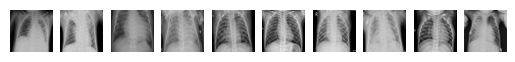

In [8]:
# Vérification des données préparées
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap="grey")
    plt.axis("off")

plt.show()

# 3. Modélisation

- Pour un transfer learning : choisir le modèle de base pré-entrainé DenseNet121

In [9]:
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Option 1: 128 neurons
x = Dense(128, activation='relu')(x)

# Option 2: 256 neurons (original)
# x = Dense(256, activation='relu')(x)

# Option 3: 512 neurons
# x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)


In [11]:
model_densenet = Model(inputs=base_model.input, outputs=predictions)


Stratégie #2 : extraction de features
On entraîne seulement le nouveau classifieur et on ne ré-entraîne pas les autres couches :

In [12]:
for layer in base_model.layers:
    layer.trainable = False


# 4. Compilation

In [13]:
model_densenet.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])


# 5. Auto-tracking 

In [14]:
import mlflow.tensorflow


mlflow.tensorflow.autolog()
mlflow.set_experiment("TL_DenseNet")

2025/05/28 17:29:59 INFO mlflow.tracking.fluent: Experiment with name 'TL_DenseNet' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/User/Desktop/DL_transfer_CNN_pneumonia/notebooks/mlruns/804736848871164847', creation_time=1748446199447, experiment_id='804736848871164847', last_update_time=1748446199447, lifecycle_stage='active', name='TL_DenseNet', tags={}>

# 5. Fitting

In [ ]:
with mlflow.start_run(run_name="Pneumonia-vs-Normal"):
    history = model_densenet.fit(
        train_generator,
        validation_data=val_generator,
        epochs=5,
        batch_size=32,
        shuffle=True
    )
     # log the model
    mlflow.keras.log_model(model_densenet,"model")
    mlflow.set_tag("model_type", "DenseNet121")
    mlflow.set_tag("dataset", "ChestX-ray")

2025/05/28 17:33:48 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/05/28 17:33:48 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
c:\Users\User\Desktop\DL_transfer_CNN_pneumonia\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7395 - loss: 0.5592

163/163 ━━━━━━━━━━━━━━━━━━━━ 583s 3s/step - accuracy: 0.7400 - loss: 0.5583 - val_accuracy: 0.7500 - val_loss: 0.5439
Epoch 2/5
117/163 ━━━━━━━━━━━━━━━━━━━━ 2:46 4s/step - accuracy: 0.8956 - loss: 0.2459

In [ ]:
model_densenet.save('../models/model_densenet.keras')


# 6. Evaluation

In [ ]:

from utils.drawing_figures import draw_accuracy_train_val_test, draw_confusion_matrix, draw_models_acc, draw_roc_curve, draw_train_val_acc_loss
mlflow.end_run()
mlflow.start_run()
# Get predictions on test data


y_pred_prob = model_densenet.predict([X_test,X_test])
y_pred = (y_pred_prob > 0.5).astype(int)



path = "../figures/densenet/"

# Confusion matrix
draw_confusion_matrix(y_test,y_pred,path)


# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pneumonia']))

# ROC score
draw_roc_curve(y_test,y_pred_prob,path)


# Accuracy & loss subplots
draw_train_val_acc_loss(history,path)


# Model accuracy train vs val vs test
draw_accuracy_train_val_test(model_densenet,history,X_test,y_test,True,path)



---

# Mlflow ui
Pour visualiser les expérimentations suivies 
- changer de répertoire:
cd  notebooks/
- entrer la commande
`mlflow ui `
- ouvrir http://localhost:5000